In [1]:
import numpy as np 
import xarray as xr 
import scipy 
import matplotlib.pyplot as plt  # Plotting library
import cartopy, cartopy.crs as ccrs  # Plot maps
import random 
import satcmaps as cmaps
import image_retrieval as img
import goesRequest2 as goes 
from recenterIR import recenter_ir

In [ ]:
def calculate_degrees(dataset): # Adapted from https://www.star.nesdis.noaa.gov/atmospheric-composition-training/python_abi_lat_lon.php
    # Read in GOES ABI fixed grid projection variables and constants
    x_coordinate_1d = dataset['x']  # E/W scanning angle in radians
    y_coordinate_1d = dataset['y']  # N/S elevation angle in radians
    projection_info = dataset['goes_imager_projection']
    lon_origin = projection_info.longitude_of_projection_origin
    H = projection_info.perspective_point_height + projection_info.semi_major_axis
    r_eq = projection_info.semi_major_axis
    r_pol = projection_info.semi_minor_axis
    
    # Create 2D coordinate matrices from 1D coordinate vectors
    x_coordinate_2d, y_coordinate_2d = np.meshgrid(x_coordinate_1d, y_coordinate_1d)
    
    # Ignore numpy errors for sqrt of negative number; occurs for GOES-16 ABI CONUS sector data
    np.seterr(all='ignore')

    # Equations to calculate latitude and longitude
    lambda_0 = (lon_origin*np.pi)/180.0  
    a_var = np.power(np.sin(x_coordinate_2d),2.0) + (np.power(np.cos(x_coordinate_2d),2.0)*(np.power(np.cos(y_coordinate_2d),2.0)+(((r_eq*r_eq)/(r_pol*r_pol))*np.power(np.sin(y_coordinate_2d),2.0))))
    b_var = -2.0*H*np.cos(x_coordinate_2d)*np.cos(y_coordinate_2d)
    c_var = (H**2.0)-(r_eq**2.0)
    r_s = (-1.0*b_var - np.sqrt((b_var**2)-(4.0*a_var*c_var)))/(2.0*a_var)
    s_x = r_s*np.cos(x_coordinate_2d)*np.cos(y_coordinate_2d)
    s_y = - r_s*np.sin(x_coordinate_2d)
    s_z = r_s*np.cos(x_coordinate_2d)*np.sin(y_coordinate_2d)
    
    abi_lat = (180.0/np.pi)*(np.arctan(((r_eq*r_eq)/(r_pol*r_pol))*((s_z/np.sqrt(((H-s_x)*(H-s_x))+(s_y*s_y))))))
    abi_lon = (lambda_0 - np.arctan(s_y/(H-s_x)))*(180.0/np.pi)

    x_coordinate_1d.close()
    y_coordinate_1d.close()
    projection_info.close()
    dataset.close()
    
    return abi_lat, abi_lon


In [ ]:
def reproject(dataset, lats, lons, pos):   
    size = 3.6
    IR = dataset['CMI'].data - 273.15
                        
    # Extents and interpolation for IR
    minimglat = pos[0] - size
    maximglat = pos[0] + size
    minimglon = pos[1] - size
    maximglon = pos[1] + size
    res = 0.0179985     # degrees resolution at nadir
    grid = np.meshgrid(np.arange(minimglat, maximglat, res), np.arange(minimglon, maximglon, res))
    
    lats = lats.flatten()
    lons = lons.flatten()
    IR = IR.flatten()
    
    # Fix shape issue for boolean conditions
    floater_IR = (np.greater(lats, minimglat) & np.greater(maximglat, lats) &
                    np.greater(lons, minimglon) & np.greater(maximglon, lons) & np.isfinite(IR))

    gridded_data = scipy.interpolate.griddata((lats[floater_IR], lons[floater_IR]), IR[floater_IR], (grid[0], grid[1]), method='linear')
    
    dataset.close()

    return grid[1], grid[0], gridded_data

In [ ]:
def rePoPolar(dataset, lats, lons, center = None):
    if center is None:
        clat = np.nanmean(lats)
        clon = np.nanmean(lons)
    else:
        clat, clon = center

    R = 6371.0
    cphi = np.cos(np.radians(clat))
    x = R * np.radians(lons - clon) * cphi
    y = R * np.radians(lats - clat)

    r = np.sqrt(x**2 + y**2)
    t = np.arctan2(y, x)

    rBins = np.linspace(0, 500, 500)
    tBins = np.linspace(np.nanmin(t), np.nanmax(t), 200)

    R, T = np.meshgrid(rBins, tBins)
    newX, newY = R * np.cos(T), R * np.sin(T)
    gridded_data = scipy.interpolate.griddata((x.flatten(), y.flatten()), dataset.flatten(), (newX.flatten(), newY.flatten()), method='nearest')

    polar = xr.Dataset(
        {
            'data': (('r', 'theta'), gridded_data.reshape(R.shape).transpose())
        },
        coords={
            'r': rBins,
            'theta': tBins
        }
    )

    polar = polar.sel(r = slice(0, 500))
    polar = polar.interp(r = np.arange(0, 500, 1))

    return x, y, polar['data']


In [ ]:
def runv2(polar):
    data = np.array([np.nanmean(polar.values, axis = 1), np.nanstd(polar.values, axis = 1)])

    return data

In [2]:
def compute(ir_azi, ir_std):
    from scipy.ndimage import gaussian_filter1d

    ir_std = gaussian_filter1d(ir_std, sigma = 6)
    radii = np.arange(0, 500, 1)#polar.r.values

    diff = (np.diff(ir_std) / np.diff(radii))
    diff2_std = np.diff(diff) / np.diff(radii[1:])
    diff2 = np.diff(ir_azi) / np.diff(radii)
    diff2 = gaussian_filter1d(diff2, sigma = 2)

    min_ir_rad, min_ir_radARG = radii[np.nanargmin(ir_azi)], np.nanargmin(ir_azi)
    min_ir_temp = np.nanmin(ir_azi)
    try:
        eyerad, eyeradARG = radii[np.nanargmin(diff2[:np.nanargmin(ir_azi)])], np.nanargmin(diff2[:np.nanargmin(ir_azi)]) 
    except:
        eyerad, eyeradARG = 0, 0
    eyetemp = np.nanmax(ir_azi[radii < min_ir_rad])
    try:
        icdoedge, icdoedgeARG = (eyerad + min_ir_rad) / 2, int((eyeradARG + min_ir_radARG) / 2)
    except:
        icdoedge, icdoedgeARG = eyerad, eyeradARG
    tempArray = np.arange(0, 499, dtype = 'float32')

    temp = int(min_ir_radARG)
    thresh = min_ir_temp + 10
    zeroPoint = temp + np.where((ir_azi[temp:] > thresh))[0][0]
    ocdoedge, ocdoedgeARG = radii[zeroPoint], zeroPoint

    cdostd = np.nanmean(ir_std[icdoedgeARG:int(ocdoedgeARG)])
    mincdostd = np.nanmin(ir_std[icdoedgeARG:int(ocdoedgeARG)])
    maxcdostd = np.nanmax(ir_std[icdoedgeARG:int(ocdoedgeARG)])

    cdorad = ocdoedge - eyerad

    return np.array([ocdoedge, eyerad, min_ir_temp, min_ir_rad, eyetemp, cdostd, mincdostd, maxcdostd])

In [ ]:
def getStormParams(dataset, satt, year, month, day, time, loc, locType = 'first'):
    t = f'{year}-{str(month).zfill(2)}-{str(day).zfill(2)}_{time}'
    
    allLats, allLons = calculate_degrees(dataset)
    lons, lats, data = reproject(dataset, allLats, allLons, loc)
    dataset.close()
    xkm, ykm, polar = rePoPolar(data, lats, lons, center = loc)
    if locType.lower() == 'best':
        tc_center_lon, tc_center_lat, yloc, xloc, mean_score = recenter_ir(data, xkm, ykm, 10, lons, lats)
        if (tc_center_lat, tc_center_lon) != (np.nan, np.nan):
            loc = (tc_center_lat, tc_center_lon)
            print('New Coordinates: ', tc_center_lat, tc_center_lon)

            xkm, ykm, polar = rePoPolar(data, lats, lons, center = loc)
        else:
            xkm, ykm, polar = rePoPolar(data, lats, lons, center = loc)

    processedData = runv2(polar)

    return processedData, polar, loc

In [ ]:
import numpy as np
import xarray as xr 
import s3fs
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import datetime
import warnings 
warnings.simplefilter(action='ignore', category=UserWarning)

# Function that retrieves GOES-R data based on satellite and requested band (single band format)
# Resulting file is called "goesfile.nc"
# Data is returned at full resolution, regardless of band
def getData(satellite, year, month, day, time, band, loc, meso = False, num = 1):
    date = datetime.date(year, month, day)
    date = date.timetuple().tm_yday
    hour = time[0:2] 

    fs = s3fs.S3FileSystem(anon=True)
    fs.ls('s3://noaa-goes16/')
    
    if meso == True:
        name = f'CMIPM'
    else:
        name = 'CMIPF'

    files = fs.ls(f'noaa-goes{satellite}/ABI-L2-{name}/{str(year)}/{str(date)}/{str(hour).zfill(2)}/')
    files = np.array(files)

    l = []
    for x in range(len(files)):
        if ((f'M6C{band.zfill(2)}' in files[x]) or (f'M4C{band.zfill(2)}' in files[x]) or (f'M3C{band.zfill(2)}' in files[x])):
            if meso == True and (f'CMIPM{num}' in files[x]):
                l.append(files[x])
            elif 'CMIPF' in files[x]:
                l.append(files[x])
            
    for x in range(len(l)):
        if f"s{year}{date}{time}" in l[x]:
            file = l[x]
            break
            
    try:
        fs.get(file, r"C:\Users\deela\Downloads\goesLoopfile3.nc")
        with xr.open_dataset(r"C:\Users\deela\Downloads\goesLoopfile3.nc") as data:
            time = (data.time_coverage_start).split('T')
            time = f"{time[0]} at {time[1][:5]} UTC"
            params, processedFile, loc = getStormParams(data, satellite, year, month, day, time, loc, locType = 'best')

            data.close()
    except Exception as e:
        print(e)
        time = 'Failed.'
        params, processedFile, loc = np.array([[np.nan for x in range(0, 500)], [np.nan for x in range(0, 500)]]), np.nan, loc
    return params, processedFile, time, loc

In [3]:
import numpy as np

satt = '19'
band = '13'

year = 2025
month = 10
day = 28
times = [f"{h:02d}{m:02d}" for h in range(0, 18) for m in range(0, 60, 1)]# + [f"{h:02d}{m:02d}" for h in range(0, 18) for m in range(0, 60, 10)] 
bPos = np.array([[0, 16.5, -78.6], [6, 16.9, -78.4], [12, 17.5, -78.1], [15, 17.9, -77.9], [18, 18.2, -77.9]]).T
bTime = bPos[0]
bLat = bPos[1]
bLon = bPos[2]

bTarget = np.arange(0, 18, 1 / 60)
bLat = np.interp(bTarget, bTime, bLat)
bLon = np.interp(bTarget, bTime, bLon)

In [4]:
print(bTarget.shape, bLat.shape, bLon.shape, len(times))
# print(bTarget)
print(times)
print(bLat, bLon)

(1080,) (1080,) (1080,) 1080
['0000', '0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010', '0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020', '0021', '0022', '0023', '0024', '0025', '0026', '0027', '0028', '0029', '0030', '0031', '0032', '0033', '0034', '0035', '0036', '0037', '0038', '0039', '0040', '0041', '0042', '0043', '0044', '0045', '0046', '0047', '0048', '0049', '0050', '0051', '0052', '0053', '0054', '0055', '0056', '0057', '0058', '0059', '0100', '0101', '0102', '0103', '0104', '0105', '0106', '0107', '0108', '0109', '0110', '0111', '0112', '0113', '0114', '0115', '0116', '0117', '0118', '0119', '0120', '0121', '0122', '0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130', '0131', '0132', '0133', '0134', '0135', '0136', '0137', '0138', '0139', '0140', '0141', '0142', '0143', '0144', '0145', '0146', '0147', '0148', '0149', '0150', '0151', '0152', '0153', '0154', '0155', '0156', '0157', '0158', '0159', '0200', '0

In [ ]:
IRData = []
files = []
locations = []
change = False
for x in range(0, len(bTarget)):
    time = times[x]
    if bTarget[x] >= 24 and change == False:
        change = True 
        day = day + 1
    loc = (bLat[x], bLon[x])
    print(x, ': ', year, month, day, time, float(bLat[x]), float(bLon[x]))
    data, f, t, l = getData(satt, year, month, day, time, band, loc, meso = True, num = 1)
    print(t, 'Eye Temperature: ', np.nanmax(data[0]), 'C\nMin Temperature: ', np.nanmin(data[0]), '\n')
    IRData.append(data)
    files.append(f)
    locations.append(l)
print(IRData)

In [ ]:
# band = '09'
# WVData = []
# for x in range(0, len(bTarget)):
#     time = times[x]
#     loc = (bLat[x], bLon[x])
#     print(year, month, day, time, loc)
#     data = getData(satt, year, month, day, time, band, loc)
#     print(x, np.nanmax(data))
#     WVData.append(data)
# print(WVData)

In [31]:
# print(np.array(IRData).shape, np.array(WVData).shape)
# allData = np.array(IRData) - np.array(WVData)
# print(allData.shape)
# allData = np.array(IRData)# - np.array(WVData)
# print(allData.shape)

allDataFile = xr.open_dataset(r"C:\Users\deela\Downloads\mel1028netcdf.nc")
files = allDataFile['data']
files = files.rename({'radius': 'r'})

allDataFile = allDataFile['data']#.sel(theta = slice(7 * np.pi / 16, 9 * np.pi / 16))
allData = np.array([allDataFile.mean('theta').values, allDataFile.std('theta').values]).transpose(1, 0, 2)

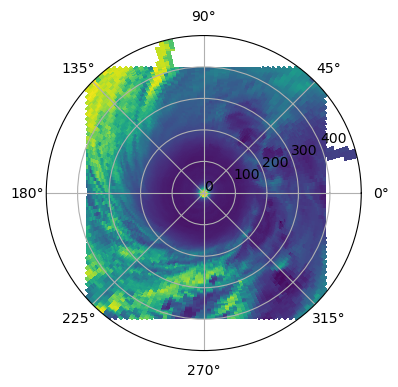

In [32]:
fig = plt.figure(figsize = (18, 9))
ax = fig.add_subplot(2, 3, 1, polar=True)
ax.pcolormesh(allDataFile.theta, allDataFile.radius, allDataFile.isel(time = 850))
plt.show()

In [33]:
params = []
for x in range(len(allData)):
    try:
        l = compute(allData[x, 0], allData[x, 1])
    except:
        l = np.array([np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan])
    params.append(l)
params = np.array(params)

cdoRad = params[:, 0]
eyeRad = params[:, 1]
minTmp = params[:, 2]
minRad = params[:, 3]
eyeTmp = params[:, 4]
cdoStd = params[:, 5]
minStd = params[:, 6]
maxStd = params[:, 7]

500 1080 1080


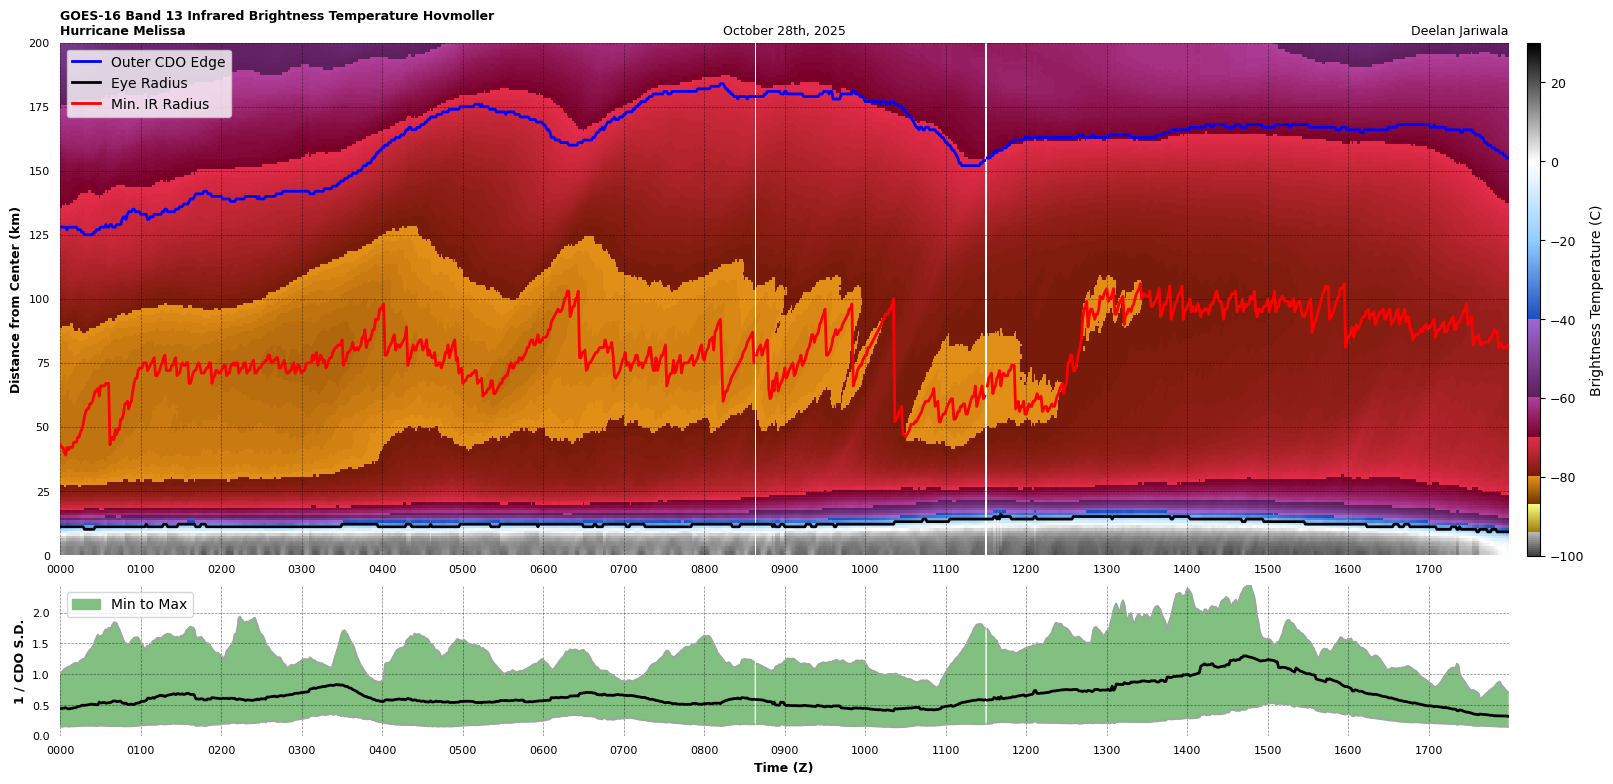

In [39]:
data = allData[:, 0].T
v = 60

yLabels = [times[x] for x in range(len(times)) if x % v == 0]
xCoord = np.arange(0, len(data[0]))
yCoord = np.arange(0, len(data))

import satcmaps as cmaps
cmap = 'ir10'
cmap, vmax, vmin = cmaps.irtables[cmap.lower()]

fig = plt.figure(figsize=(18, 9))
gs = fig.add_gridspec(4, 1, wspace = 0, hspace = 0.2, right=0.93)

ax = fig.add_subplot(gs[0:3, 0])
ax2 = fig.add_subplot(gs[3, 0], sharex = ax)

ax.set_frame_on(False)
ax2.set_frame_on(False)

# Add state boundaries to plot
ax.tick_params(axis='both', labelsize=8, left = False, bottom = False)
ax.grid(linestyle = '--', alpha = 0.5, color = 'black', linewidth = 0.5, zorder = 9)
ax.set_ylabel('Distance from Center (km)', weight = 'bold', size = 9)
ax2.set_xlabel('Time (Z)', weight = 'bold', size = 9)
ax.set_xticks(np.arange(0, len(times), v))
ax.set_xticklabels(yLabels)
ax.set_ylim(0, 200)

c = ax.pcolormesh(xCoord, yCoord, data, cmap = cmap, vmax = vmax, vmin = vmin)
# c = plt.contourf(np.arange(0, len(allData[0])), np.arange(0, len(allData)), allData, cmap = cmap, levels = np.arange(vmin, vmax + 1, 1))
print(len(data), len(data[0]), len(cdoRad))
ax.plot(xCoord, cdoRad, color = 'blue', linewidth = 2, label = 'Outer CDO Edge')
ax.plot(xCoord, eyeRad, color = 'black', linewidth = 2, label = 'Eye Radius')
ax.plot(xCoord, minRad, color = 'red', linewidth = 2, label = 'Min. IR Radius')

ax.legend(loc = 'upper left')

ax2.set_xticks(np.arange(0, len(times), v))
ax2.set_xticklabels(yLabels)
ax2.grid(linestyle = '--', alpha = 0.5, color = 'black', linewidth = 0.5, zorder = 9)
ax2.tick_params(axis='both', labelsize=8, left = False, bottom = False)
ax2.plot(xCoord, 1 / cdoStd, color = 'black', linewidth = 2)
ax2.fill_between(xCoord, 1 / minStd, 1 / maxStd, color='#81c081', label = 'Min to Max')
ax2.plot(xCoord, 1 / minStd, color = '#98ab98', zorder = 50, linewidth = 1.5)
ax2.plot(xCoord, 1 / maxStd, color = '#98ab98', zorder = 50, linewidth = 1.5)
# ax2.plot(np.arange(0, len(data[0])), eyeTmp, color = 'black', linewidth = 2, label = 'Eye Temp')
# ax2.plot(np.arange(0, len(data[0])), minTmp, color = 'red', linewidth = 2, label = 'Min. IR Temp')
ax2.set_ylabel('1 / CDO S.D.', weight = 'bold', size = 9)
ax2.set_ylim(0, 2.45)
ax2.legend(loc = 'upper left')

ax.set_title(f'GOES-16 Band {band} Infrared Brightness Temperature Hovmoller\nHurricane Melissa', fontweight='bold', fontsize=9, loc='left')
ax.set_title(f'October 28th, {year}', fontsize=9, loc='center') 
ax.set_title(f'Deelan Jariwala', fontsize=9, loc='right') 
cbar_ax = fig.add_axes([0.94, 0.31, 0.0075, 0.57])
cbar = plt.colorbar(c, orientation = 'vertical', cax = cbar_ax, label = 'Brightness Temperature (C)')
cbar.ax.tick_params(axis='both', labelsize=9, left = False, bottom = False)
plt.savefig(r"C:\Users\deela\Downloads\hovmollerIRBD.png", dpi = 400, bbox_inches = 'tight')
plt.show()

In [ ]:
yLabels = [times[x] for x in range(len(times)) if x % 60 == 0]

data = allData[:, 0]

import satcmaps as cmaps
cmap = 'irg'
cmap, vmax, vmin = cmaps.irtables[cmap.lower()]

fig = plt.figure(figsize=(12, 12))

# Add the map and set the extent
ax = plt.axes()
ax.set_frame_on(False)

# Add state boundaries to plot
ax.tick_params(axis='both', labelsize=8, left = False, bottom = False)
ax.grid(linestyle = '--', alpha = 0.5, color = 'black', linewidth = 0.5, zorder = 9)
ax.set_xlabel('Distance from Center (km)', weight = 'bold', size = 9)
ax.set_ylabel('Time (Z)', weight = 'bold', size = 9)
ax.set_yticks(np.arange(0, len(times), 60))
ax.set_yticklabels(yLabels)
ax.set_xlim(0, 200)

c = plt.pcolormesh(np.arange(0, len(data[0])), np.arange(0, len(data)), data, cmap = cmap, vmax = vmax, vmin = vmin)
# c = plt.contourf(np.arange(0, len(allData[0])), np.arange(0, len(allData)), allData, cmap = cmap, levels = np.arange(vmin, vmax + 1, 1))

plt.plot(cdoRad, np.arange(0, len(data)), color = 'blue', linewidth = 2, label = 'Outer CDO Edge')
plt.plot(eyeRad, np.arange(0, len(data)), color = 'black', linewidth = 2, label = 'Outer CDO Edge')
plt.plot(minRad, np.arange(0, len(data)), color = 'red', linewidth = 2, label = 'Outer CDO Edge')

plt.legend(loc = 'lower right')

ax.set_title(f'GOES-19 Band {band} Infrared Brightness Temperature Hovmoller\nHurricane Melissa', fontweight='bold', fontsize=9, loc='left')
ax.set_title(f'October 28th, {year}', fontsize=9, loc='center') 
ax.set_title(f'Deelan Jariwala', fontsize=9, loc='right') 
cbar = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02, label = 'Brightness Temperature (C)')
cbar.ax.tick_params(axis='both', labelsize=9, left = False, bottom = False)
plt.savefig(r"C:\Users\deela\Downloads\hovmollerIRNorth.png", dpi = 400, bbox_inches = 'tight')
plt.show()

In [ ]:
yLabels = [times[x] for x in range(len(times)) if x % 60 == 0]

testData = np.diff(allData[:, 0], axis = 1)
print(testData.shape)

import cmaps as cmp
import satcmaps as cmaps
cmap = 'irg'
cmap, vmax, vmin = cmaps.irtables[cmap.lower()]

fig = plt.figure(figsize=(12, 12))

# Add the map and set the extent
ax = plt.axes()
ax.set_frame_on(False)

# Add state boundaries to plot
ax.tick_params(axis='both', labelsize=8, left = False, bottom = False)
ax.grid(linestyle = '--', alpha = 0.5, color = 'black', linewidth = 0.5, zorder = 9)
ax.set_xlabel('Distance from Center (km)', weight = 'bold', size = 9)
ax.set_ylabel('Time (Z)', weight = 'bold', size = 9)
ax.set_yticks(np.arange(0, len(times), 60))
ax.set_yticklabels(yLabels)
ax.set_xlim(0, 200)
# ax.set_ylim(180, 240)

# c = plt.pcolormesh(np.arange(0, len(testData[0])), np.arange(0, len(testData)), testData, cmap = cmp.tempAnoms3(), vmin = -10, vmax = 10)
c = plt.contourf(np.arange(0, len(testData[0])), np.arange(0, len(testData)), testData, cmap = cmp.tempAnoms3(), levels = np.arange(-0.5, 0.505, .005), extend = 'both')

ax.set_title(f'GOES-19 Band {band} Infrared Brightness Temperature Hovmoller\nHurricane Melissa', fontweight='bold', fontsize=9, loc='left')
ax.set_title(f'October {day}th, {year}', fontsize=9, loc='center') 
ax.set_title(f'Deelan Jariwala', fontsize=9, loc='right') 
cbar = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02, label = 'Radial Derivative')
cbar.ax.tick_params(axis='both', labelsize=9, left = False, bottom = False)
plt.savefig(r"C:\Users\deela\Downloads\melissahovmollerGrad2North.png", dpi = 400, bbox_inches = 'tight')
plt.show()

In [ ]:
import cmaps as cmaps

data = allData[:, 0]

threshold = -60

yLabels = [times[x] for x in range(len(times)) if x % 60 == 0]

temp = np.where(data < threshold, data, np.nan)
temp = (np.nanmax(temp) - temp) / (np.nanmax(temp) - np.nanmin(temp))

fig = plt.figure(figsize=(12, 12))

# Add the map and set the extent
ax = plt.axes()
ax.set_frame_on(False)

# Add state boundaries to plot
ax.tick_params(axis='both', labelsize=8, left = False, bottom = False)
ax.grid(linestyle = '--', alpha = 0.5, color = 'black', linewidth = 0.5, zorder = 9)
ax.set_xlabel('Distance from Center (km)', weight = 'bold', size = 9)
ax.set_ylabel('Time (Z)', weight = 'bold', size = 9)
ax.set_yticks(np.arange(0, len(times), 60))
ax.set_yticklabels(yLabels)
ax.set_xlim(0, 150)

c = plt.pcolormesh(np.arange(0, len(temp[0])), np.arange(0, len(temp)), temp, cmap = cmaps.probs4(), vmax = 1, vmin = 0)

ax.set_title(f'GOES-19 Band {band} Infrared Brightness Temperature Hovmoller\nHurricane Melissa', fontweight='bold', fontsize=9, loc='left')
ax.set_title(f'October {day}th, {year}', fontsize=9, loc='center') 
ax.set_title(f'Data < {threshold}C\nDeelan Jariwala', fontsize=9, loc='right') 
cbar = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02, label = 'Normalized IR BT')
cbar.ax.tick_params(axis='both', labelsize=9, left = False, bottom = False)
# plt.savefig(r"C:\Users\deela\Downloads\melissahovmollerIRFiltered.png", dpi = 400, bbox_inches = 'tight')
plt.show()

In [ ]:
import cmaps as cmaps

data = allData[:, 0]

threshold = -75

yLabels = [times[x] for x in range(len(times)) if x % 60 == 0]

temp = data - np.nanmean(data, axis = 0)

fig = plt.figure(figsize=(12, 12))

# Add the map and set the extent
ax = plt.axes()
ax.set_frame_on(False)

# Add state boundaries to plot
ax.tick_params(axis='both', labelsize=8, left = False, bottom = False)
ax.grid(linestyle = '--', alpha = 0.5, color = 'black', linewidth = 0.5, zorder = 9)
ax.set_xlabel('Distance from Center (km)', weight = 'bold', size = 9)
ax.set_ylabel('Time (Z)', weight = 'bold', size = 9)
ax.set_yticks(np.arange(0, len(times), 60))
ax.set_yticklabels(yLabels)
ax.set_xlim(0, 200)

c = plt.pcolormesh(np.arange(0, len(temp[0])), np.arange(0, len(temp)), temp, cmap = cmaps.tempAnoms3(), vmax = 5, vmin = -5)

ax.set_title(f'GOES-19 Band {band} Infrared Brightness Temperature Hovmoller\nHurricane Melissa', fontweight='bold', fontsize=9, loc='left')
ax.set_title(f'October {day}th, {year}', fontsize=9, loc='center') 
ax.set_title(f'Subtract Time Mean\nDeelan Jariwala', fontsize=9, loc='right') 
cbar = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02, label = 'Normalized IR BT')
cbar.ax.tick_params(axis='both', labelsize=9, left = False, bottom = False)
# plt.savefig(r"C:\Users\deela\Downloads\melissahovmollerIRTest.png", dpi = 400, bbox_inches = 'tight')
plt.show()

In [ ]:
yLabels = [times[x] for x in range(len(times)) if x % 60 == 0]

data = allData[:, 1]

import cmaps as cmp
import satcmaps as cmaps
from scipy.ndimage import gaussian_filter

cmap = 'rbtop3'
cmap, vmax, vmin = cmaps.irtables[cmap.lower()]

fig = plt.figure(figsize=(12, 12))

# Add the map and set the extent
ax = plt.axes()
ax.set_frame_on(False)

# Add state boundaries to plot
ax.tick_params(axis='both', labelsize=8, left = False, bottom = False)
ax.grid(linestyle = '--', alpha = 0.5, color = 'black', linewidth = 0.5, zorder = 9)
ax.set_xlabel('Distance from Center (km)', weight = 'bold', size = 9)
ax.set_ylabel('Time (Z)', weight = 'bold', size = 9)
ax.set_yticks(np.arange(0, len(times), 60))
ax.set_yticklabels(yLabels)
ax.set_xlim(0, 200)

c = plt.pcolormesh(np.arange(0, len(data[0])), np.arange(0, len(data)), 1 / data, cmap = cmp.probs4(), vmin = 0, vmax = 5)
# c = plt.contourf(np.arange(0, len(data[0])), np.arange(0, len(data)), gaussian_filter(1 / data, sigma = 1), cmap = cmp.probs4(), levels = np.arange(0, 2.51, .01), extend = 'max')

plt.plot(cdoRad, np.arange(0, len(data)), color = 'blue', linewidth = 2, label = 'Outer CDO Edge')
plt.plot(eyeRad, np.arange(0, len(data)), color = 'white', linewidth = 2, label = 'Eye Radius')
plt.plot(minRad, np.arange(0, len(data)), color = 'red', linewidth = 2, label = 'Min. IR Temp')

plt.legend(loc = 'lower right')

ax.set_title(f'GOES-19 Band {band} Infrared Brightness Temperature Symmetry Hovmoller\nHurricane Melissa', fontweight='bold', fontsize=9, loc='left')
ax.set_title(f'October {day}th, {year}', fontsize=9, loc='center') 
ax.set_title(f'Deelan Jariwala', fontsize=9, loc='right') 
cbar = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02, label = 'Inverse of the Standard Deviation of Each Ring')
cbar.ax.tick_params(axis='both', labelsize=9, left = False, bottom = False)
plt.savefig(r"C:\Users\deela\Downloads\melissahovmollerIRSTDtestNorth.png", dpi = 400, bbox_inches = 'tight')
plt.show()

In [ ]:
maxSym = np.inf
maxRad = -np.inf
negTmp = np.inf
posTmp = -np.inf

t = 0
i = 0
for x in range(len(times)):
    if cdoStd[x] < maxSym and cdoRad[x] > maxRad and eyeTmp[x] > posTmp:
        maxSym = cdoStd[x]
        maxRad = cdoRad[x]
        negTmp = minTmp[x]
        posTmp = eyeTmp[x]
        t = times[x]
        i = x
print(t, 1 / maxSym, maxRad, negTmp, posTmp, bLon[i], bLat[i])

In [11]:
a = []
for x in files:
    try:
        shape = x.values.shape
        a.append(x.values)
    except:
        a.append(np.full(shape, np.nan))

a =  np.array(a)
print(a.shape)

(1080, 500, 200)


In [12]:
T = a.shape[0]
t = np.arange(T)

# subtract mean so NaNs don’t break things
am = np.nanmean(a, axis=0, keepdims=True)
d = a - am

# replace remaining NaNs with 0 (after mean subtraction they contribute nothing)
d = np.nan_to_num(d, nan=0)

# slope formula: cov(t, x) / var(t)
t_mean = t.mean()
num = np.sum((t - t_mean)[:,None,None] * d, axis=0)
den = np.sum((t - t_mean)**2)

slope = num / den

(1080, 500)


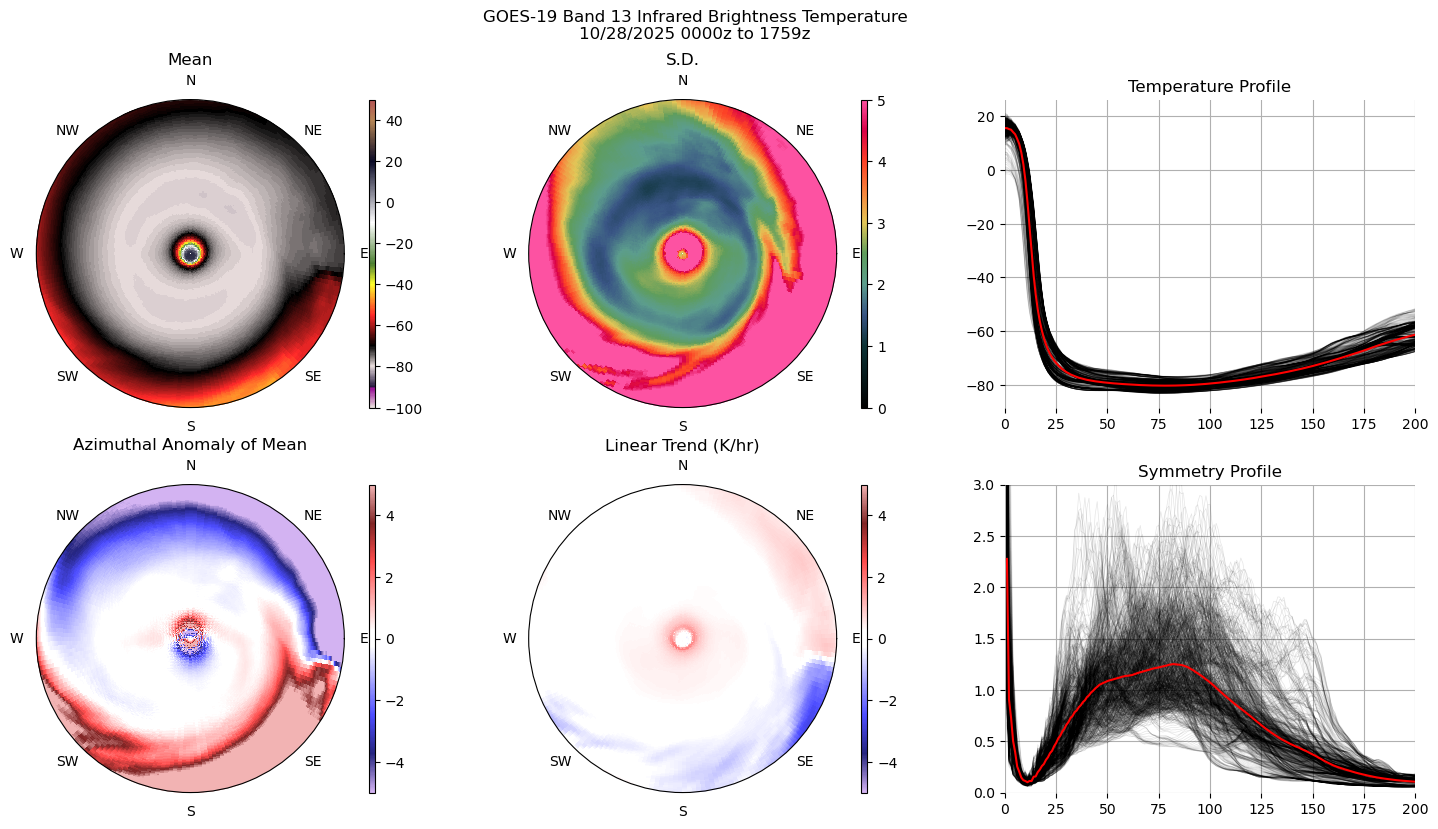

In [15]:
from satcmaps import irg
from cmaps import probs4, tempAnoms3

fig = plt.figure(figsize = (18, 9))

ax = fig.add_subplot(2, 3, 1, polar=True)
c = ax.pcolormesh(files[0].theta, files[0].r, np.nanmean(a, axis = 0), vmin = -100, vmax = 50, cmap = irg()[0])
ax.set_rlim(0, 200)
plt.colorbar(c, aspect = 50, pad = 0.06)
ax.set_title('Mean')
ax.grid(False)
ax.set_yticklabels([])
ax.set_xticklabels(['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE'])

ax2 = fig.add_subplot(2, 3, 2, polar=True)
c = ax2.pcolormesh(files[0].theta, files[0].r, np.nanstd(a, axis = 0), vmin = 0, vmax = 5, cmap = probs4())
ax2.set_rlim(0, 200)
plt.colorbar(c, aspect = 50, pad = 0.06)
ax2.set_title('S.D.')
ax2.grid(False)
ax2.set_yticklabels([])
ax2.set_xticklabels(['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE'])

ax3 = fig.add_subplot(2, 3, 4, polar=True)
anomaly = np.nanmean(a, axis=0) - np.nanmean(a, axis=(0,2))[:, None]
c = ax3.pcolormesh(files[0].theta, files[0].r, anomaly, vmin = -5, vmax = 5, cmap = tempAnoms3())
ax3.set_rlim(0, 200)
plt.colorbar(c, aspect = 50, pad = 0.06)
ax3.set_title('Azimuthal Anomaly of Mean')
ax3.grid(False)
ax3.set_yticklabels([])
ax3.set_xticklabels(['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE'])

ax4 = fig.add_subplot(2, 3, 5, polar=True)
c = ax4.pcolormesh(files[0].theta, files[0].r, slope * 60, vmin = -5, vmax = 5, cmap = tempAnoms3())
ax4.set_rlim(0, 200)
plt.colorbar(c, aspect = 50, pad = 0.06)
ax4.set_title('Linear Trend (K/hr)')
ax4.grid(False)
ax4.set_yticklabels([])
ax4.set_xticklabels(['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE'])

allSTD = 1 / np.nanstd(a, axis = 2)
allAVG = np.nanmean(a, axis = 2)

print(allSTD.shape)

ax5 = fig.add_subplot(2, 3, 3)
ax5.set_frame_on(False)
ax5.grid(True)
ax5.set_xlim(0, 200)
ax5.set_title('Temperature Profile')

ax6 = fig.add_subplot(2, 3, 6)
ax6.set_frame_on(False)
ax6.grid(True)
ax6.set_ylim(0, 3)
ax6.set_xlim(0, 200)
ax6.set_title('Symmetry Profile')

ax5.plot(allAVG.T, color = 'black', linewidth = 0.5, alpha = 0.1)
ax6.plot(allSTD.T, color = 'black', linewidth = 0.5, alpha = 0.1)

ax5.plot(np.nanmean(allAVG, axis = 0), color = 'red', linewidth = 1.5)
ax6.plot(np.nanmean(allSTD, axis = 0), color = 'red', linewidth = 1.5)

fig.subplots_adjust(hspace=0.25)

plt.suptitle(f'GOES-19 Band {band} Infrared Brightness Temperature\n{month}/{day}/{year} {times[0]}z to {times[-1]}z')
plt.savefig(r"C:\Users\deela\Downloads\idkwhattocallit.png", dpi = 400, bbox_inches = 'tight')
plt.show()

In [ ]:
from satcmaps import irg
from cmaps import probs4, tempAnoms3

for f in range(len(a)):
    frame = a[f]
    fig = plt.figure(figsize = (18, 9))

    ax = fig.add_subplot(2, 3, 1, polar=True)
    c = ax.pcolormesh(files[0].theta, files[0].r, frame, vmin = -100, vmax = 50, cmap = irg()[0])
    ax.set_rlim(0, 200)
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax.set_title('Mean')
    ax.grid(False)
    ax.set_yticklabels([])
    ax.set_xticklabels(['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE'])

    ax2 = fig.add_subplot(2, 3, 2, polar=True)
    c = ax2.pcolormesh(files[0].theta, files[0].r, frame - np.nanmean(a, axis = 0), vmin = -5, vmax = 5, cmap = tempAnoms3())
    ax2.set_rlim(0, 200)
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax2.set_title('Time-Mean Anomaly')
    ax2.grid(False)
    ax2.set_yticklabels([])
    ax2.set_xticklabels(['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE'])

    ax3 = fig.add_subplot(2, 3, 3, polar=True)
    anomaly = frame - np.nanmean(frame, axis=1)[:, None]
    c = ax3.pcolormesh(files[0].theta, files[0].r, anomaly, vmin = -5, vmax = 5, cmap = tempAnoms3())
    ax3.set_rlim(0, 200)
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax3.set_title('Azimuthal-Mean Anomaly')
    ax3.grid(False)
    ax3.set_yticklabels([])
    ax3.set_xticklabels(['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE'])

    ax4 = fig.add_subplot(2, 3, 4, polar=True)
    trend = frame - a[f - 1]
    c = ax4.pcolormesh(files[0].theta, files[0].r, trend, vmin = -2, vmax = 2, cmap = tempAnoms3())
    ax4.set_rlim(0, 200)
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax4.set_title('Difference From Previous')
    ax4.grid(False)
    ax4.set_yticklabels([])
    ax4.set_xticklabels(['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE'])

    fig.subplots_adjust(hspace=0.25)

    plt.suptitle(f'GOES-19 Band {band} Infrared Brightness Temperature\n{month}/{day}/{year} {times[f]}z')
    plt.savefig(r"C:\Users\deela\Downloads\pulse\\" + str(f) + ".png", dpi = 200, bbox_inches = 'tight')
    plt.close()

In [ ]:
from scipy.ndimage import gaussian_filter
from satcmaps import irg
from cmaps import probs4, tempAnoms3

gauss = False

for f in range(len(a)):
    frame = a[f]
    fig = plt.figure(figsize = (18, 9))

    ax1 = fig.add_subplot(2, 3, 1, polar=True)
    c = ax1.pcolormesh(files[0].theta, files[0].r, frame, vmin = -100, vmax = 50, cmap = irg()[0])
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax1.set_title('Mean')

    ax2 = fig.add_subplot(2, 3, 2, polar=True)
    if gauss == True:
        tempThing = gaussian_filter(frame - np.nanmean(a, axis = 0), sigma = 2)
    else:
        tempThing = frame - np.nanmean(a, axis = 0)
    c = ax2.pcolormesh(files[0].theta, files[0].r, tempThing, vmin = -5, vmax = 5, cmap = tempAnoms3())
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax2.set_title('Time-Mean Anomaly')

    ax3 = fig.add_subplot(2, 3, 4, polar=True)
    if gauss == True:
        anomaly = gaussian_filter(frame - np.nanmean(frame, axis=1)[:, None], sigma = 2)
    else:
        anomaly = frame - np.nanmean(frame, axis=1)[:, None]
    c = ax3.pcolormesh(files[0].theta, files[0].r, anomaly, vmin = -5, vmax = 5, cmap = tempAnoms3())
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax3.set_title('Azimuthal-Mean Anomaly')

    ax4 = fig.add_subplot(2, 3, 5, polar=True)
    if gauss == True:
        trend = gaussian_filter(frame - a[f - 1], sigma = 2)
    else:
        trend = frame - a[f - 1]
    c = ax4.pcolormesh(files[0].theta, files[0].r, trend, vmin = -2, vmax = 2, cmap = tempAnoms3())
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax4.set_title('Difference From Previous')

    axes = [ax1, ax2, ax3, ax4]
    for ax in axes:
        ax.set_rlim(0, 120)
        ax.grid(False)
        ax.set_yticklabels([])
        ax.set_xticklabels(['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE'])
        ax.plot(np.linspace(0, 2*np.pi, 360), np.full(360, eyeRad[f]), color = 'black', linewidth = 2)

    allSTD = 1 / np.nanstd(a, axis = 2)
    allAVG = np.nanmean(a, axis = 2)
    
    ax5 = fig.add_subplot(2, 3, 3)
    ax5.set_frame_on(False)
    ax5.grid(True)
    ax5.set_xlim(0, 120)
    ax5.set_title('Temperature Profile')

    ax6 = fig.add_subplot(2, 3, 6)
    ax6.set_frame_on(False)
    ax6.grid(True)
    ax6.set_ylim(0, 3)
    ax6.set_xlim(0, 120)
    ax6.set_title('Symmetry Profile')

    ax5.plot(allAVG.T, color = 'black', linewidth = 0.5, alpha = 0.1)
    ax6.plot(allSTD.T, color = 'black', linewidth = 0.5, alpha = 0.1)

    ax5.plot(allAVG[f], color = 'red', linewidth = 1.5)
    ax6.plot(allSTD[f], color = 'red', linewidth = 1.5)

    fig.subplots_adjust(hspace=0.25)

    plt.suptitle(f'GOES-19 Band {band} Infrared Brightness Temperature\n{month}/{day}/{year} {times[f]}z')
    plt.savefig(r"C:\Users\deela\Downloads\pulseZoom\\" + str(f) + ".png", dpi = 200, bbox_inches = 'tight')
    plt.close()

In [ ]:
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from satcmaps import irg
from cmaps import probs4, tempAnoms3

gauss = False
localMean = True 

for f in range(len(a)):
    radiusUsed = 75 
    frame = a[f]
    fig = plt.figure(figsize = (18, 9))

    ax1 = fig.add_subplot(2, 3, 1, polar=True)
    c = ax1.pcolormesh(files[0].theta, files[0].r, frame, vmin = -100, vmax = 50, cmap = irg()[0])
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax1.set_title('Mean')

    ax2 = fig.add_subplot(2, 3, 2, polar=True)
    if localMean == True:
        mean = gaussian_filter1d(a, sigma=10, axis=0, mode='reflect')[f]
    else:
        mean = np.nanmean(a, axis = 0)
    if gauss == True:
        tempThing = gaussian_filter(frame - mean, sigma = 2)
    else:
        tempThing = frame - mean
    c = ax2.pcolormesh(files[0].theta, files[0].r, tempThing, vmin = -2, vmax = 2, cmap = tempAnoms3())
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax2.set_title('Time-Mean Anomaly')

    ax3 = fig.add_subplot(2, 3, 4, polar=True)
    if gauss == True:
        anomaly = gaussian_filter(frame - np.nanmean(frame, axis=1)[:, None], sigma = 2)
    else:
        anomaly = frame - np.nanmean(frame, axis=1)[:, None]
    c = ax3.pcolormesh(files[0].theta, files[0].r, anomaly, vmin = -5, vmax = 5, cmap = tempAnoms3())
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax3.set_title('Azimuthal-Mean Anomaly')

    ax4 = fig.add_subplot(2, 3, 5, polar=True)
    if gauss == True:
        trend = gaussian_filter(frame - a[f - 1], sigma = 2)
    else:
        trend = frame - a[f - 1]
    c = ax4.pcolormesh(files[0].theta, files[0].r, trend, vmin = -2, vmax = 2, cmap = tempAnoms3())
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax4.set_title('Difference From Previous')

    axes = [ax1, ax2, ax3, ax4]
    for ax in axes:
        ax.set_rlim(0, 125)
        ax.grid(False)
        ax.set_yticklabels([])
        ax.set_xticklabels(['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE'])
        ax.plot(np.linspace(0, 2*np.pi, 360), np.full(360, radiusUsed), color = 'black', linewidth = 2)

    print(f, 'Eye Radius: ', eyeRad[f])

    allAVG = gaussian_filter1d(a[:, int(radiusUsed)], axis = 1, sigma = 2)
    
    ax5 = fig.add_subplot(2, 3, 3)
    ax5.set_frame_on(False)
    ax5.grid(True)
    ax5.set_title(f'Temperature Profile at {radiusUsed}km')
    ax5.axhline(0, linewidth = 2, color = 'black')
    ax5.set_ylim(-86, -72)
    ax5.set_xticks([-np.pi, -3 * np.pi / 4, -np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
    ax5.set_xticklabels(['W', 'SW', 'S', 'SE', 'E', 'NE', 'N', 'NW', 'W'])

    ax6 = fig.add_subplot(2, 3, 6)
    ax6.set_frame_on(False)
    ax6.grid(True)
    ax6.set_title(f'Change from Previous ({radiusUsed}km)')
    ax6.axhline(0, linewidth = 2, color = 'black')
    ax6.set_ylim(-2, 2)
    ax6.set_xticks([-np.pi, -3 * np.pi / 4, -np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
    ax6.set_xticklabels(['W', 'SW', 'S', 'SE', 'E', 'NE', 'N', 'NW', 'W'])

    ax5.plot(files[0].theta, allAVG.T, color = 'black', linewidth = 0.5, alpha = 0.1)

    ax5.plot(files[0].theta, allAVG[f], color = 'red', linewidth = 1.5)
    ax6.plot(files[0].theta, allAVG[f] - allAVG[f - 1], color = 'red', linewidth = 1.5)

    fig.subplots_adjust(hspace=0.25)

    plt.suptitle(f'GOES-19 Band {band} Infrared Brightness Temperature\n{month}/{day}/{year} {times[f]}z', fontsize = 14)
    plt.savefig(r"C:\Users\deela\Downloads\pulseZoom3\\" + str(f) + ".png", dpi = 200, bbox_inches = 'tight')
    plt.close()


In [30]:
# meso in eye

from scipy.ndimage import gaussian_filter, gaussian_filter1d
from satcmaps import irg
from cmaps import probs4, tempAnoms3, tempAnoms6

gauss = False
localMean = True 

for f in range(len(a)):
    radiusUsed = 75  #125 if 75 is radius
    frame = a[f]
    fig = plt.figure(figsize = (18, 9))

    ax1 = fig.add_subplot(2, 3, 1, polar=True)
    c = ax1.pcolormesh(files[0].theta, files[0].r, frame, vmin = -100, vmax = 50, cmap = irg()[0])
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax1.set_title('Mean')

    ax2 = fig.add_subplot(2, 3, 2, polar=True)
    if localMean == True:
        mean = gaussian_filter1d(a, sigma=10, axis=0, mode='reflect')[f]
    else:
        mean = np.nanmean(a, axis = 0)
    if gauss == True:
        tempThing = gaussian_filter(frame - mean, sigma = 2)
    else:
        tempThing = frame - mean
    c = ax2.pcolormesh(files[0].theta, files[0].r, tempThing, vmin = -5, vmax = 5, cmap = tempAnoms6())
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax2.set_title('Time-Mean Anomaly')

    ax3 = fig.add_subplot(2, 3, 4, polar=True)
    if gauss == True:
        anomaly = gaussian_filter(frame - np.nanmean(frame, axis=1)[:, None], sigma = 2)
    else:
        anomaly = frame - np.nanmean(frame, axis=1)[:, None]
    c = ax3.pcolormesh(files[0].theta, files[0].r, anomaly, vmin = -10, vmax = 10, cmap = tempAnoms6())
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax3.set_title('Azimuthal-Mean Anomaly')

    ax4 = fig.add_subplot(2, 3, 5, polar=True)
    if gauss == True:
        trend = gaussian_filter(frame - a[f - 1], sigma = 2)
    else:
        trend = frame - a[f - 1]
    c = ax4.pcolormesh(files[0].theta, files[0].r, trend, vmin = -3, vmax = 3, cmap = tempAnoms6())
    plt.colorbar(c, aspect = 50, pad = 0.06)
    ax4.set_title('Difference From Previous')

    axes = [ax1, ax2, ax3, ax4]
    for ax in axes:
        ax.set_rlim(0, 125)
        ax.grid(False)
        ax.set_yticklabels([])
        ax.set_xticklabels(['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE'])
        ax.plot(np.linspace(0, 2*np.pi, 360), np.full(360, radiusUsed), color = 'black', linewidth = 2)

    print(f, 'Eye Radius: ', eyeRad[f])

    if gauss == True:
        allAVG = gaussian_filter1d(a[:, int(radiusUsed)], axis = 1, sigma = 2)
        nthAVG = gaussian_filter1d(a[:, 0:75, 50], axis = 1, sigma = 2)
    else:
        allAVG = a[:, int(radiusUsed)]
        nthAVG = a[:, 0:75, 50]

    ax5 = fig.add_subplot(2, 3, 3)
    ax5.set_frame_on(False)
    ax5.grid(True)
    ax5.set_title(f'Change from Previous 0-{str(int(radiusUsed))}km (S)')
    ax5.axhline(0, linewidth = 2, color = 'black')
    ax5.set_ylim(-5, 5)
    # ax5.set_xticks([-np.pi, -3 * np.pi / 4, -np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
    # ax5.set_xticklabels(['W', 'SW', 'S', 'SE', 'E', 'NE', 'N', 'NW', 'W'])

    ax6 = fig.add_subplot(2, 3, 6)
    ax6.set_frame_on(False)
    ax6.grid(True)
    ax6.set_title(f'Change from Previous ({radiusUsed}km)')
    ax6.axhline(0, linewidth = 2, color = 'black')
    ax6.set_ylim(-2.5, 2.5)
    ax6.set_xticks([-np.pi, -3 * np.pi / 4, -np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
    ax6.set_xticklabels(['W', 'SW', 'S', 'SE', 'E', 'NE', 'N', 'NW', 'W'])

    # ax5.plot(np.arange(len(nthAVG.T)), nthAVG.T, color = 'black', linewidth = 0.5, alpha = 0.1)

    ax5.plot(np.arange(len(nthAVG.T)), nthAVG[f] - nthAVG[f - 1], color = 'red', linewidth = 1.5)
    ax6.plot(files[0].theta, allAVG[f] - allAVG[f - 1], color = 'red', linewidth = 1.5)

    fig.subplots_adjust(hspace=0.25)

    plt.suptitle(f'GOES-19 Band {band} Infrared Brightness Temperature\n{month}/{day}/{year} {times[f]}z', fontsize = 14)
    plt.savefig(r"C:\Users\deela\Downloads\pulseZoom2\\" + str(f) + ".png", dpi = 200, bbox_inches = 'tight')
    plt.close()


0 Eye Radius:  10.0
1 Eye Radius:  10.0
2 Eye Radius:  10.0
3 Eye Radius:  9.0
4 Eye Radius:  9.0
5 Eye Radius:  11.0
6 Eye Radius:  11.0
7 Eye Radius:  11.0
8 Eye Radius:  11.0
9 Eye Radius:  11.0
10 Eye Radius:  11.0
11 Eye Radius:  11.0
12 Eye Radius:  11.0
13 Eye Radius:  11.0
14 Eye Radius:  10.0
15 Eye Radius:  10.0
16 Eye Radius:  10.0
17 Eye Radius:  9.0
18 Eye Radius:  12.0
19 Eye Radius:  12.0
20 Eye Radius:  12.0
21 Eye Radius:  11.0
22 Eye Radius:  11.0
23 Eye Radius:  11.0
24 Eye Radius:  11.0
25 Eye Radius:  11.0
26 Eye Radius:  11.0
27 Eye Radius:  11.0
28 Eye Radius:  11.0
29 Eye Radius:  10.0
30 Eye Radius:  10.0
31 Eye Radius:  10.0
32 Eye Radius:  10.0
33 Eye Radius:  10.0
34 Eye Radius:  10.0
35 Eye Radius:  12.0
36 Eye Radius:  12.0
37 Eye Radius:  12.0
38 Eye Radius:  12.0
39 Eye Radius:  11.0
40 Eye Radius:  11.0
41 Eye Radius:  11.0
42 Eye Radius:  11.0
43 Eye Radius:  11.0
44 Eye Radius:  11.0
45 Eye Radius:  11.0
46 Eye Radius:  10.0
47 Eye Radius:  10.0
48 Ey

(1080, 500, 200)


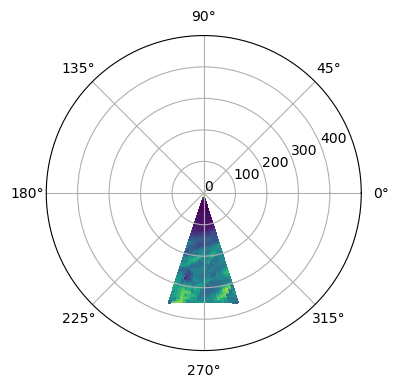

In [22]:
print(a.shape)
fig = plt.figure(figsize = (18, 9))
ax4 = fig.add_subplot(2, 3, 5, polar=True)
plt.pcolormesh(files[0].theta[40:60], files[0].r, a[0, :, 40:60])
plt.show()

In [ ]:
print(files[0].theta.shape)
print(files[0].r.shape)

In [ ]:
print(a.shape)
ds = xr.Dataset({'data'      : (["time", "radius", "theta"], a)}, 
    coords =   {"time": [np.datetime64(f'{str(year)}-{str(month).zfill(2)}-{str(day).zfill(2)}T{i[:2]}:{i[2:]}') for i in times],
                "radius" : files[0].r.values,
                "theta" : files[0].theta.values})
ds.to_netcdf(r"C:\Users\deela\Downloads\mel1028netcdf.nc")

In [ ]:
print(xr.open_dataset(r"C:\Users\deela\Downloads\mel1028netcdf.nc"))

In [ ]:
locations = np.array(locations)
print(locations.shape)

In [ ]:
import cartopy.feature as cfeature
from cartopy.geodesic import Geodesic
import cmaps as cmp 

fig = plt.figure(figsize=(18, 9))

# Add the map and set the extent
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_frame_on(False)

# Add state boundaries to plot
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth = 0.75)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth = 0.25)
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth = 0.25)  
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth = 1, color='gray', alpha=0.5, linestyle='--')   
gl.top_labels = gl.right_labels = False

ax.set_extent([-79, -77, 16.5, 18.3])

c = ax.scatter(locations[:, 1], locations[:, 0], s = 10, c = cdoRad - minRad, cmap = cmp.probs4())

ax.set_title(f'GOES-19 Band {band} Infrared Brightness Temperature Center Locations\nHurricane Melissa', fontweight='bold', fontsize=9, loc='left')
ax.set_title(f'October {day}th, {year} 06z to 18z', fontsize=9, loc='center') 
ax.set_title(f'Deelan Jariwala', fontsize=9, loc='right') 
cbar = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02, label = 'Range of Standard Deviation')
cbar.ax.tick_params(axis='both', labelsize=9, left = False, bottom = False)
# plt.savefig(r"C:\Users\deela\Downloads\melissahovmollercenters.png", dpi = 400, bbox_inches = 'tight')
plt.show()